# Similaridade de cosseno da matriz de consumo C

Este notebook lê a matriz **C (67 × 67)** exportada por `analise_matriz_insumo_produto.ipynb`. O vetor de consumo por atividade, chamado `consumo_co2` naquele notebook, corresponde a `C.sum(axis=0)` e não é a entrada desta análise.

- **Linhas:** atividades emissoras, agregando Brasil e exterior representativo. Sua similaridade compara a distribuição das emissões entre atividades da demanda final brasileira.
- **Colunas:** atividades da demanda final brasileira. Sua similaridade compara a composição das emissões por atividade emissora.

C inclui emissões nacionais, importações finais e importações intermediárias. Herda as hipóteses do notebook de origem: MIP 2015, intensidades interpoladas de 2011/2018, aproximação monetária e exterior com intensidades e tecnologia brasileiras.

Execute as células na ordem. A entrada deve existir em `outputs/matriz_emissoes_consumo_2015.csv`; para regenerá-la, execute primeiro o notebook da MIP. Este notebook pode ser iniciado da raiz do repositório ou desta pasta.

In [1]:
from pathlib import Path
from hashlib import sha256
import platform

import numpy as np
import pandas as pd
from IPython.display import display

raiz = Path.cwd().resolve()
if not (raiz / "analise_matriz_insumo_produto.ipynb").is_file():
    raiz = raiz.parent
if not (raiz / "analise_matriz_insumo_produto.ipynb").is_file():
    raise FileNotFoundError("Execute a partir da raiz do repositório ou de similaridade_consumo.")
pasta = raiz / "similaridade_consumo"
entrada = raiz / "outputs" / "matriz_emissoes_consumo_2015.csv"


## 1. Entrada e conferência dos eixos

Preservamos os códigos como texto, a ordem das atividades, os valores originais e a diagonal de C. Não aplicamos logaritmo, centralização nem exclusão de relações internas. O SHA-256 abaixo identifica os bytes efetivamente analisados; não certifica sua equivalência ao manifesto canônico.

In [2]:
C = pd.read_csv(entrada, dtype={"atividade_emissora": str}, index_col="atividade_emissora")
C.columns = C.columns.astype(str)
C = C.apply(pd.to_numeric, errors="raise")
assert C.shape == (67, 67), "Esperada matriz C com 67 atividades."
assert C.index.is_unique and C.columns.is_unique
assert C.index.equals(C.columns), "As atividades dos dois eixos devem estar alinhadas."
assert np.isfinite(C.to_numpy()).all(), "C contém valores ausentes ou infinitos."
assert (C.to_numpy() >= 0).all(), "Rever a interpretação para emissões negativas."

print("Entrada:", entrada.relative_to(raiz))
print("SHA-256:", sha256(entrada.read_bytes()).hexdigest())
print("Python:", platform.python_version(), "| NumPy:", np.__version__, "| pandas:", pd.__version__)
print("Dimensão:", C.shape, "| Unidade: Gg de CO₂")
display(C.iloc[:5, :5])


Entrada: outputs\matriz_emissoes_consumo_2015.csv
SHA-256: cbc6a595f72f234caf1bfa4ec84885d5e804540bbfc9ccd4c480273298fa0238
Python: 3.12.10 | NumPy: 2.2.6 | pandas: 3.0.0
Dimensão: (67, 67) | Unidade: Gg de CO₂
                           0191         0192  ...       0580        0680
atividade_emissora                            ...                       
0191                2153.031855    73.950304  ...   0.267772    4.350501
0192                   9.245007  1669.160013  ...   0.037720    0.604441
0280                  47.906198    70.204795  ...   0.124584    2.325668
0580                  29.167514    17.376302  ...  61.226480    8.193601
0680                  25.144631    11.688987  ...   0.340419  217.618413

[5 rows x 5 columns]


## 2. Definição e tratamento de vetores nulos

Para dois vetores não nulos $u$ e $v$:

$$s(u,v)=\frac{u\cdot v}{\|u\|_2\|v\|_2}.$$

Com valores não negativos, a similaridade varia de 0 (sem componentes positivas compartilhadas) a 1 (perfis proporcionais). Multiplicar um vetor por uma constante positiva não altera o resultado: similaridade não mede volume de emissões nem causalidade.

Normalizamos cada linha de C pela sua norma euclidiana e multiplicamos a matriz normalizada por sua transposta. Para colunas, normalizamos cada coluna e invertemos a ordem desse produto. Vetores nulos recebem **NaN** em todas as comparações, inclusive consigo mesmos, porque o cosseno é indefinido nesse caso. A diagonal das similaridades vale 1 para vetores não nulos.

In [3]:
valores = C.to_numpy(dtype=float)
normas_linhas = np.linalg.norm(valores, axis=1)
normas_colunas = np.linalg.norm(valores, axis=0)

linhas_normalizadas = np.divide(
    valores, normas_linhas[:, None],
    out=np.full_like(valores, np.nan), where=normas_linhas[:, None] > 0,
)
colunas_normalizadas = np.divide(
    valores, normas_colunas[None, :],
    out=np.full_like(valores, np.nan), where=normas_colunas[None, :] > 0,
)

# O clip corrige somente arredondamentos numéricos nos limites 0 e 1.
similaridade_linhas = pd.DataFrame(
    np.clip(linhas_normalizadas @ linhas_normalizadas.T, 0, 1),
    index=C.index.copy(), columns=C.index.copy(),
)
similaridade_colunas = pd.DataFrame(
    np.clip(colunas_normalizadas.T @ colunas_normalizadas, 0, 1),
    index=C.columns.copy(), columns=C.columns.copy(),
)
similaridade_linhas.index.name = similaridade_linhas.columns.name = "atividade_emissora"
similaridade_colunas.index.name = similaridade_colunas.columns.name = "atividade_da_demanda_final"

print("Linhas nulas:", C.index[normas_linhas == 0].tolist())
print("Colunas nulas:", C.columns[normas_colunas == 0].tolist())
print("Similaridade entre linhas — primeiras cinco atividades:")
display(similaridade_linhas.iloc[:5, :5])
print("Similaridade entre colunas — primeiras cinco atividades:")
display(similaridade_colunas.iloc[:5, :5])


Linhas nulas: []
Colunas nulas: []
Similaridade entre linhas — primeiras cinco atividades:
atividade_emissora      0191      0192      0280      0580      0680
atividade_emissora                                                  
0191                1.000000  0.192027  0.071435  0.127182  0.206238
0192                0.192027  1.000000  0.120495  0.082800  0.115234
0280                0.071435  0.120495  1.000000  0.121814  0.066869
0580                0.127182  0.082800  0.121814  1.000000  0.305955
0680                0.206238  0.115234  0.066869  0.305955  1.000000
Similaridade entre colunas — primeiras cinco atividades:
atividade_da_demanda_final      0191      0192      0280      0580      0680
atividade_da_demanda_final                                                  
0191                        1.000000  0.183099  0.035970  0.112579  0.166520
0192                        0.183099  1.000000  0.054752  0.086574  0.113877
0280                        0.035970  0.054752  1.000000  0.0

## 3. Validação dos resultados

Conferimos simetria, diagonal unitária dos vetores não nulos e ausência de resultados definidos para vetores nulos. Comparamos também cada par com a fórmula escalar aplicada diretamente à entrada, para conferir a orientação dos eixos e a normalização.

In [4]:
for vetores, normas, resultado in [
    (valores, normas_linhas, similaridade_linhas),
    (valores.T, normas_colunas, similaridade_colunas),
]:
    matriz = resultado.to_numpy()
    np.testing.assert_allclose(matriz, matriz.T, equal_nan=True)
    np.testing.assert_allclose(np.diag(matriz)[normas > 0], 1, atol=1e-12)
    assert np.isnan(matriz[normas == 0, :]).all()
    assert np.isnan(matriz[:, normas == 0]).all()
    for i in range(len(vetores)):
        for j in range(len(vetores)):
            if normas[i] > 0 and normas[j] > 0:
                esperado = np.dot(vetores[i], vetores[j]) / (normas[i] * normas[j])
                np.testing.assert_allclose(matriz[i, j], esperado, atol=1e-12)
print("Validações concluídas para linhas e colunas.")


Validações concluídas para linhas e colunas.


## 4. Exportação

As duas matrizes completas, adimensionais, são salvas nesta pasta com os códigos das atividades nos dois eixos. Códigos devem ser lidos como texto para preservar zeros iniciais. Campos `NaN`, quando presentes, indicam similaridade indefinida.

In [5]:
similaridade_linhas.to_csv(pasta / "similaridade_linhas_C.csv", encoding="utf-8", na_rep="NaN")
similaridade_colunas.to_csv(pasta / "similaridade_colunas_C.csv", encoding="utf-8", na_rep="NaN")
print("Exportadas duas matrizes 67 × 67 em", pasta.name)


Exportadas duas matrizes 67 × 67 em similaridade_consumo


## 5. Grafo bipartido: soma das linhas e diagonal de C

Representamos C em Gg de CO₂, não a similaridade de cosseno. Cada atividade aparece nos dois lados:

- **Esquerda, azul:** área proporcional à soma completa da linha, $\sum_j C_{ij}$, incluindo a diagonal. São as emissões da atividade atribuídas ao conjunto da demanda final brasileira.
- **Direita, laranja:** área proporcional a $C_{jj}$, as emissões da própria atividade atribuídas à demanda final de seus produtos. Não representa a pegada total dessa demanda final.
- **Ligações:** somente $C_{ij}>0$ com $i\ne j$, com espessura proporcional ao valor. São atribuições de emissões entre atividades diferentes, lidas da esquerda para a direita.

Os dois grupos usam a mesma escala de área. Cada lado é ordenado independentemente pelo tamanho dos nós, do maior no topo ao menor na base; empates preservam a ordem da MIP. Os tamanhos não equivalem à soma das ligações visíveis: o azul inclui a diagonal omitida, enquanto o laranja representa essa diagonal.

`limiar_gg` filtra apenas as ligações desenhadas. A cobertura informada usa como denominador a soma **fora da diagonal** de C. C permanece intacta para os cálculos de similaridade. Nós de valor zero têm área zero, mantendo seus rótulos.


In [6]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import networkx as nx

limiar_gg = 0.0  # Mostrar ligações com C_ij > limiar_gg (Gg de CO₂).
assert limiar_gg >= 0

somas_linhas = C.sum(axis=1)
somas_colunas = C.sum(axis=0)
diagonal = pd.Series(np.diag(C.to_numpy()), index=C.index, name="diagonal_gg")
setores = pd.read_csv(raiz / "outputs" / "setores_2015.csv", dtype={"atividade": str})
nomes = setores.set_index("atividade")["descricao"]
assert C.index.isin(nomes.index).all()

# O prefixo distingue os dois papéis da mesma atividade.
G = nx.Graph()
for atividade in C.index:
    G.add_node(("linha", atividade), bipartite=0, total_gg=float(somas_linhas[atividade]))
for atividade in C.columns:
    G.add_node(("coluna", atividade), bipartite=1, total_gg=float(diagonal[atividade]))
for i, origem in enumerate(C.index):
    for j, destino in enumerate(C.columns):
        peso = float(C.iloc[i, j])
        if origem != destino and peso > 0:
            G.add_edge(("linha", origem), ("coluna", destino), weight=peso)

# As ligações excluem a diagonal, mas os tamanhos usam as medidas completas.
assert nx.is_bipartite(G)
assert G.number_of_nodes() == 2 * len(C)
assert all(u[1] != v[1] for u, v in G.edges())
for atividade in C.index:
    np.testing.assert_allclose(G.degree(("linha", atividade), weight="weight"), somas_linhas[atividade] - diagonal[atividade], atol=1e-8)
    np.testing.assert_allclose(G.degree(("coluna", atividade), weight="weight"), somas_colunas[atividade] - diagonal[atividade], atol=1e-8)
np.testing.assert_allclose(G.size(weight="weight"), C.to_numpy().sum() - diagonal.sum())

posicoes = {}
for ordem, atividade in enumerate(somas_linhas.sort_values(ascending=False, kind="stable").index):
    posicoes[("linha", atividade)] = (0, -ordem)
for ordem, atividade in enumerate(diagonal.sort_values(ascending=False, kind="stable").index):
    posicoes[("coluna", atividade)] = (1, -ordem)

arestas_visiveis = [(u, v, d["weight"]) for u, v, d in G.edges(data=True) if d["weight"] > limiar_gg]
# Desenha as maiores por último para preservar sua visibilidade.
arestas_visiveis.sort(key=lambda aresta: aresta[2])
peso_total = G.size(weight="weight")
peso_visivel = sum(peso for _, _, peso in arestas_visiveis)
cobertura = peso_visivel / peso_total if peso_total > 0 else 0.0
print(f"Nós: {G.number_of_nodes()} | Ligações positivas: {G.number_of_edges()}")
print(f"Ligações visíveis: {len(arestas_visiveis)} | Cobertura fora da diagonal: {cobertura:.2%}")


Nós: 134 | Ligações positivas: 4290
Ligações visíveis: 4290 | Cobertura fora da diagonal: 100.00%


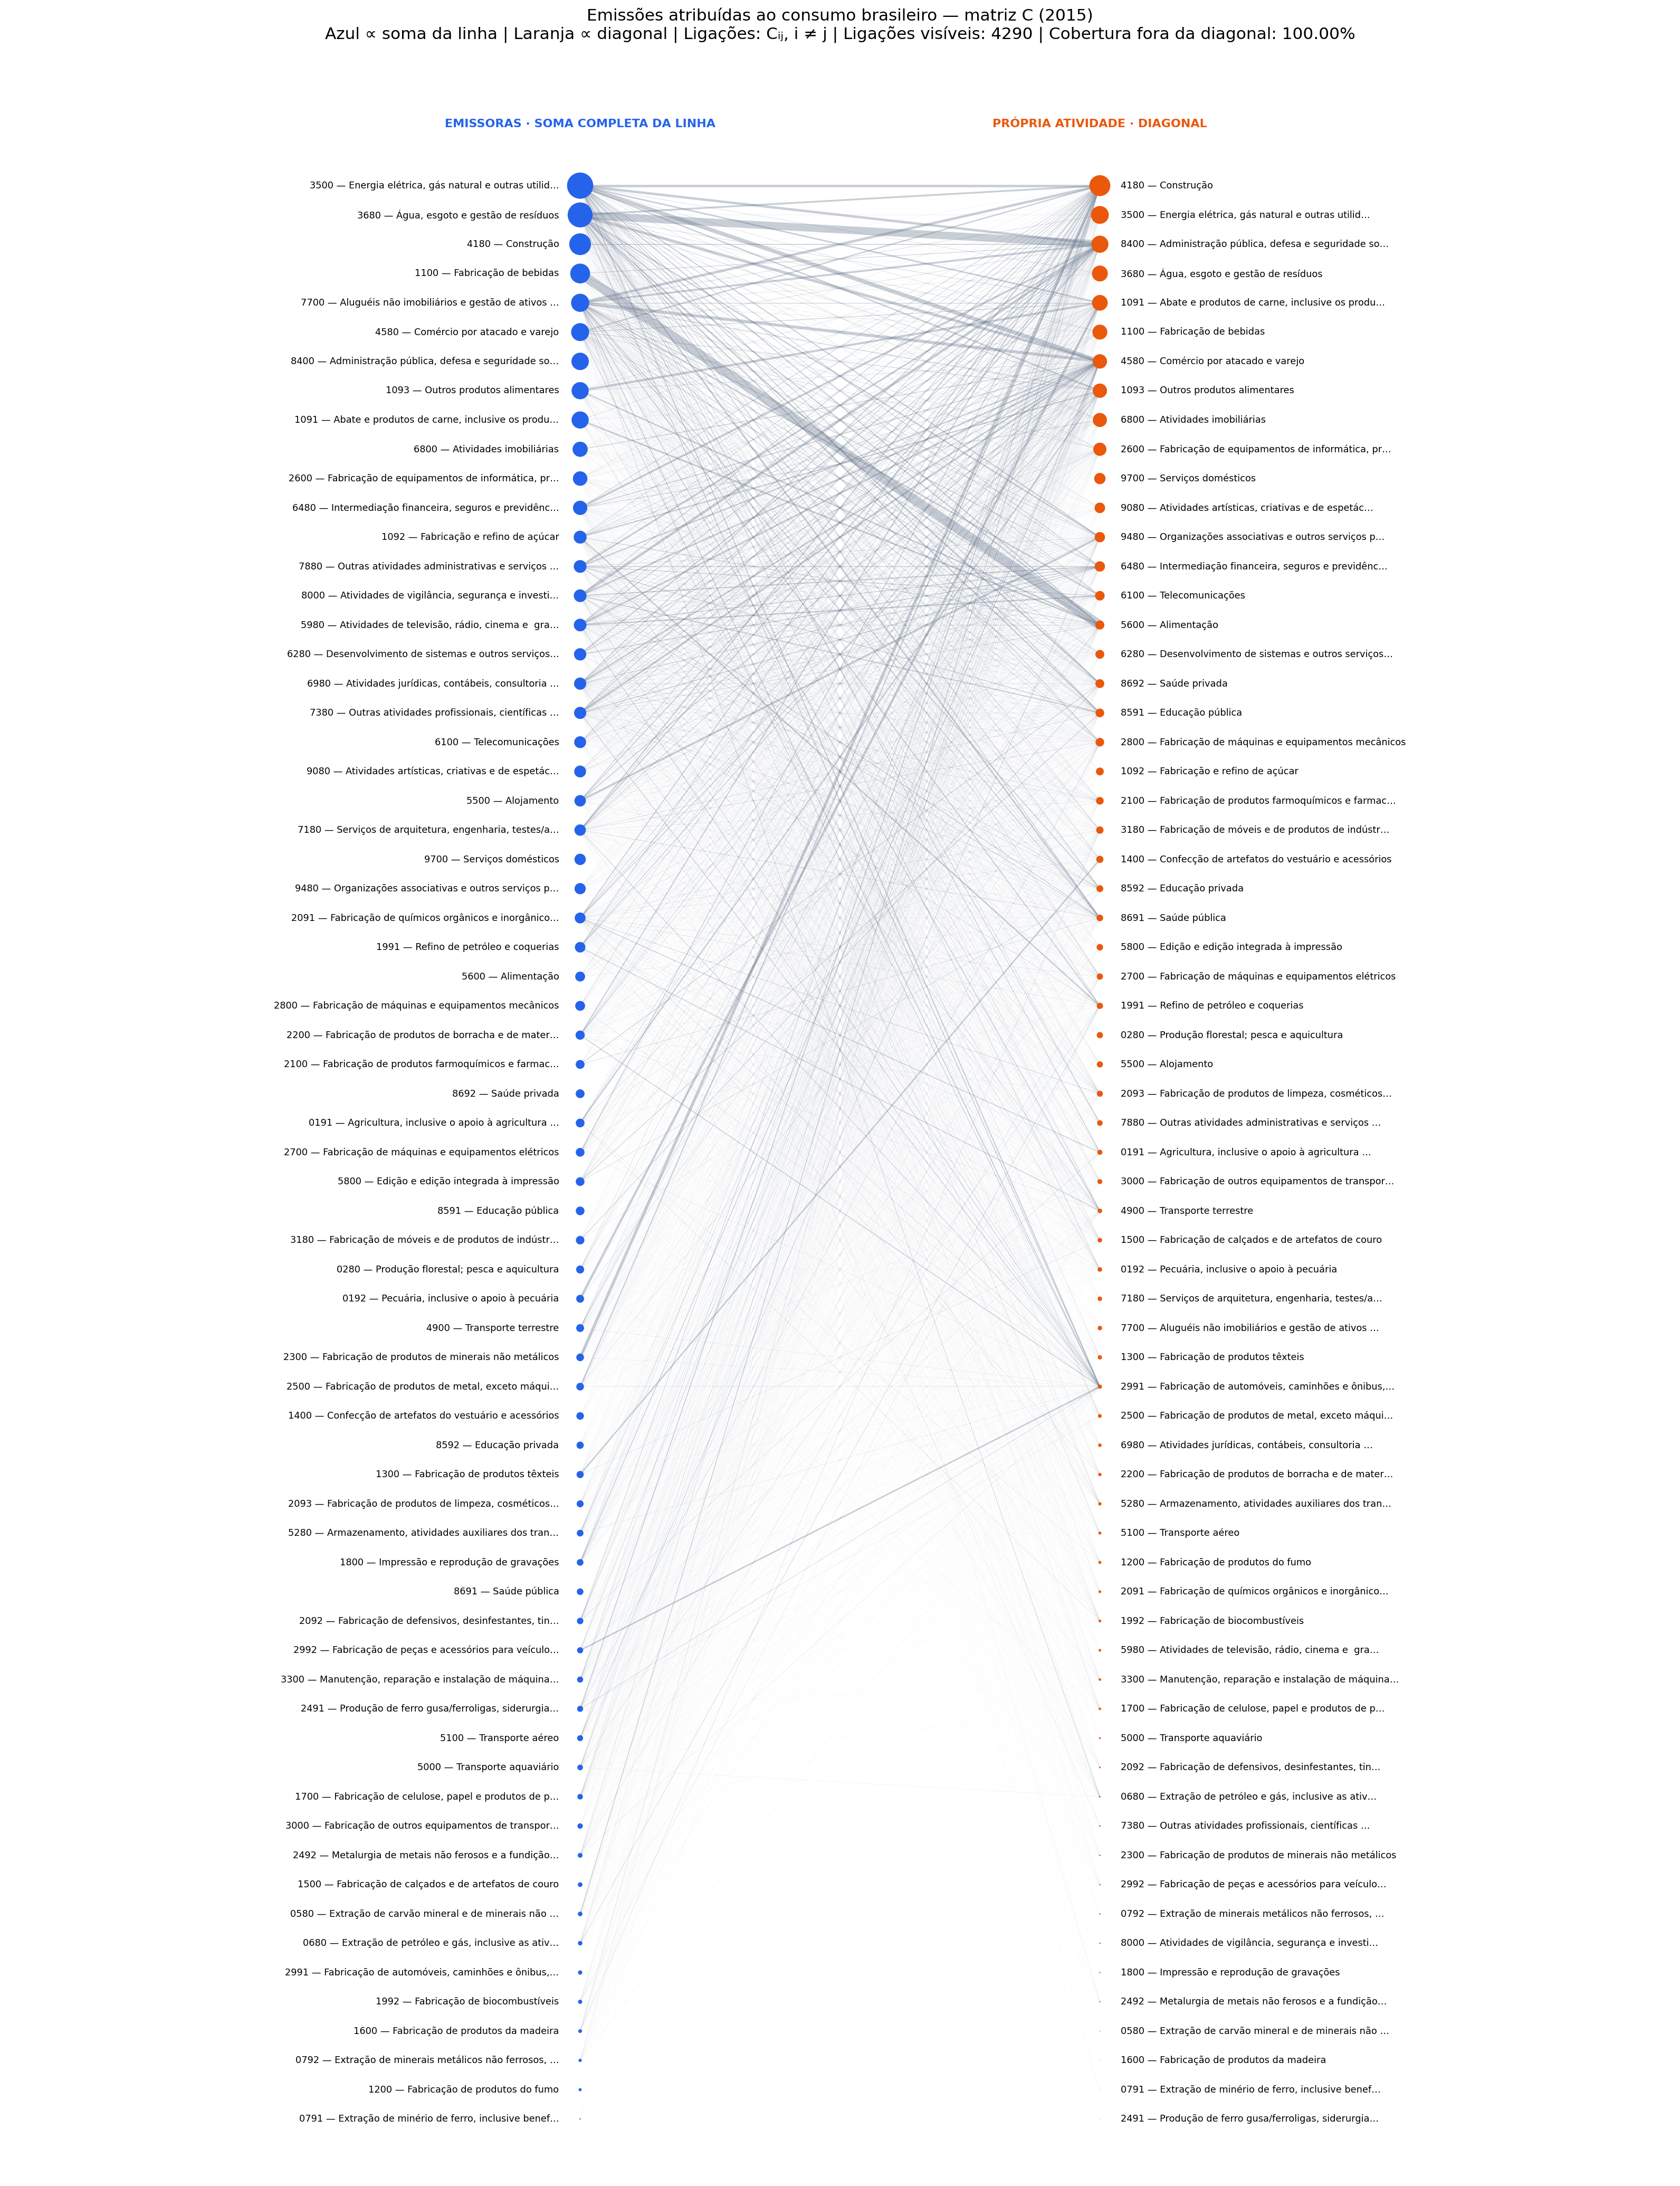

In [7]:
fig, ax = plt.subplots(figsize=(20, 26))
maior_peso = max((d["weight"] for _, _, d in G.edges(data=True)), default=0)
maior_total = max(somas_linhas.max(), diagonal.max())
area_maxima = 500  # pontos²; mesma escala para os dois grupos
espessura_maxima = 8  # pontos

segmentos = [[posicoes[u], posicoes[v]] for u, v, _ in arestas_visiveis]
espessuras = [espessura_maxima * peso / maior_peso for _, _, peso in arestas_visiveis]
ax.add_collection(LineCollection(segmentos, linewidths=espessuras, colors="#64748b", alpha=0.35, zorder=1))

for papel, somas, cor in [
    ("linha", somas_linhas, "#2563eb"),
    ("coluna", diagonal, "#ea580c"),
]:
    coords = np.array([posicoes[(papel, atividade)] for atividade in somas.index])
    areas = area_maxima * somas.to_numpy() / maior_total if maior_total > 0 else np.zeros(len(somas))
    ax.scatter(coords[:, 0], coords[:, 1], s=areas, color=cor, edgecolors="none", zorder=3)
    for atividade in somas.index:
        x_no, y_no = posicoes[(papel, atividade)]
        nome = nomes[atividade]
        # Código identifica sem ambiguidade; descrição curta facilita a leitura.
        if len(nome) > 48:
            nome = nome[:45] + "…"
        rotulo = f"{atividade} — {nome}"
        ax.annotate(rotulo, (x_no, y_no), xytext=(-18 if papel == "linha" else 18, 0),
                    textcoords="offset points", ha="right" if papel == "linha" else "left",
                    va="center", fontsize=8)

ax.text(0, 2, "EMISSORAS · SOMA COMPLETA DA LINHA", color="#2563eb", ha="center", weight="bold")
ax.text(1, 2, "PRÓPRIA ATIVIDADE · DIAGONAL", color="#ea580c", ha="center", weight="bold")
ax.set_title("Emissões atribuídas ao consumo brasileiro — matriz C (2015)\n"
             f"Azul ∝ soma da linha | Laranja ∝ diagonal | Ligações: Cᵢⱼ, i ≠ j | Ligações visíveis: {len(arestas_visiveis)} | Cobertura fora da diagonal: {cobertura:.2%}",
             fontsize=14, pad=25)
ax.set_xlim(-1.1, 2.1)
ax.set_ylim(-len(C) - 1, 4)
ax.axis("off")
fig.tight_layout()
fig.savefig(pasta / "grafo_bipartido_C_sem_diagonal.png", dpi=160, bbox_inches="tight")
fig.savefig(pasta / "grafo_bipartido_C_sem_diagonal.svg", bbox_inches="tight")
plt.show()


## 6. Sankey: atribuição de emissões entre atividades

O Sankey usa **C fora da diagonal**, mantendo o recorte do grafo anterior, com todas as ligações positivas. Azul identifica emissores e laranja identifica atividades da demanda final. A largura de cada ligação é $C_{ij}$ em Gg de CO₂.

No Sankey, a altura do nó corresponde à soma dos fluxos **exibidos**: soma da linha menos diagonal à esquerda; soma da coluna menos diagonal à direita. Portanto, a altura laranja não representa apenas a diagonal. Os totais completos e a diagonal aparecem ao passar o mouse. Cada lado é ordenado por seu fluxo exibido, do maior para o menor.

São atribuições à demanda final, não etapas físicas sucessivas de produção. O Sankey mostra volumes; as próximas figuras mostram similaridade de perfis.

In [8]:
import plotly.graph_objects as go

valores_fluxos = C.to_numpy(copy=True)
np.fill_diagonal(valores_fluxos, 0.0)
C_fluxos = pd.DataFrame(valores_fluxos, index=C.index, columns=C.columns)
fluxos_linhas = C_fluxos.sum(axis=1)
fluxos_colunas = C_fluxos.sum(axis=0)
ordem_linhas = fluxos_linhas.sort_values(ascending=False, kind="stable").index
ordem_colunas = fluxos_colunas.sort_values(ascending=False, kind="stable").index
n = len(C)
indices_linhas = {codigo: i for i, codigo in enumerate(ordem_linhas)}
indices_colunas = {codigo: n + i for i, codigo in enumerate(ordem_colunas)}

origens, destinos, pesos = [], [], []
for origem in ordem_linhas:
    for destino in ordem_colunas:
        peso = float(C_fluxos.loc[origem, destino])
        if peso > 0:
            origens.append(indices_linhas[origem])
            destinos.append(indices_colunas[destino])
            pesos.append(peso)
np.testing.assert_allclose(sum(pesos), C.to_numpy().sum() - np.trace(C.to_numpy()))
assert all(ordem_linhas[i] != ordem_colunas[j-n] for i, j in zip(origens, destinos))

rotulos, detalhes = [], []
for ordem, somas, fluxos in [(ordem_linhas, C.sum(axis=1), fluxos_linhas),
                             (ordem_colunas, C.sum(axis=0), fluxos_colunas)]:
    for codigo in ordem:
        rotulos.append(f"{codigo} — {nomes[codigo]}")
        detalhes.append([float(somas[codigo]), float(C.loc[codigo, codigo]), float(fluxos[codigo])])

# Posições verticais proporcionais aos fluxos reservam espaço para nós grandes.
posicoes_y = []
for ordem, fluxos in [(ordem_linhas, fluxos_linhas), (ordem_colunas, fluxos_colunas)]:
    f = fluxos.loc[ordem].to_numpy()
    parcelas = f / f.sum() if f.sum() > 0 else np.full(n, 1/n)
    alturas = 0.72 * parcelas + 0.26 / n
    posicoes_y.extend((0.01 + np.cumsum(alturas) - alturas/2).tolist())

fig_sankey = go.Figure(go.Sankey(
    arrangement="fixed",
    node=dict(label=rotulos, color=["#2563eb"]*n + ["#ea580c"]*n,
              x=[0.01]*n + [0.99]*n, y=posicoes_y, pad=8, thickness=16,
              customdata=detalhes,
              hovertemplate="%{label}<br>Total completo do eixo: %{customdata[0]:,.2f} Gg"
                            "<br>Diagonal: %{customdata[1]:,.2f} Gg"
                            "<br>Fluxo exibido: %{customdata[2]:,.2f} Gg<extra></extra>"),
    link=dict(source=origens, target=destinos, value=pesos,
              color="rgba(100,116,139,0.22)",
              hovertemplate="%{source.label} → %{target.label}<br>%{value:,.2f} Gg CO₂<extra></extra>"),
))
fig_sankey.update_layout(title="C sem diagonal · Emissores → Demanda final brasileira · Gg CO₂",
                         height=2200, width=1500, font=dict(size=10),
                         margin=dict(l=30, r=30, t=90, b=30), paper_bgcolor="white")
fig_sankey.show()


## 7. Similaridade dos setores: perfis de linhas e colunas

Usamos as similaridades calculadas na seção 2, a partir de **C completa, incluindo a diagonal**. A exclusão da diagonal é somente um recorte dos desenhos de fluxos: não alteramos silenciosamente a definição dos perfis.

- **Linhas:** dois emissores são semelhantes quando distribuem suas emissões entre os mesmos destinos em proporções parecidas.
- **Colunas:** duas atividades de demanda final são semelhantes quando dependem das mesmas origens emissoras em proporções parecidas.

As cores vão de 0 a 1, independentemente do volume de emissões. Uma diagonal própria dominante pode reduzir a similaridade entre setores diferentes. A diagonal das matrizes de similaridade (comparação de um perfil consigo mesmo) vale 1 e é ocultada somente nos mapas e nos rankings.

Ordenamos os mapas por agrupamento hierárquico com ligação média e dissimilaridade $1-s$. Isso aproxima perfis semelhantes no desenho; não define grupos econômicos nem um número de clusters. A ordem é a mesma nos dois eixos de cada mapa, mas pode diferir entre os mapas. Vetores nulos, se existirem, ficam fora do agrupamento e ao fim do mapa com comparações indefinidas.

In [9]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform, cdist

figuras_similaridade = {}
pares_similares = {}
for tipo, similaridade, perfis in [
    ("linhas", similaridade_linhas, C.to_numpy()),
    ("colunas", similaridade_colunas, C.to_numpy().T),
]:
    # Conferência independente das similaridades dos perfis originais.
    np.testing.assert_allclose(similaridade.to_numpy(), 1-cdist(perfis, perfis, metric="cosine"),
                               atol=1e-12, equal_nan=True)
    validos = similaridade.index[np.isfinite(np.diag(similaridade))]
    indefinidos = similaridade.index[~np.isfinite(np.diag(similaridade))]
    if len(validos) > 1:
        distancias = np.clip(1-similaridade.loc[validos, validos].to_numpy(), 0, 1)
        distancias = (distancias + distancias.T)/2
        np.fill_diagonal(distancias, 0)
        arvore = linkage(squareform(distancias), method="average", optimal_ordering=True)
        ordem = validos[leaves_list(arvore)].tolist() + indefinidos.tolist()
    else:
        ordem = validos.tolist() + indefinidos.tolist()
    mapa = similaridade.loc[ordem, ordem].to_numpy(copy=True)
    np.fill_diagonal(mapa, np.nan)
    descricoes = [f"{codigo} — {nomes[codigo]}" for codigo in ordem]
    fig = go.Figure(go.Heatmap(
        z=mapa, x=descricoes, y=descricoes, zmin=0, zmax=1,
        colorscale="Viridis", colorbar=dict(title="Cosseno"), hoverongaps=False,
        hovertemplate="%{y}<br>%{x}<br>Similaridade: %{z:.4f}<extra></extra>",
    ))
    fig.update_layout(title=f"Similaridade de cosseno entre {tipo} de C · diagonal própria ocultada",
                      height=1100, width=1400, margin=dict(l=360, b=240, t=80, r=80))
    fig.update_xaxes(tickmode="array", tickvals=descricoes, ticktext=ordem, tickangle=90)
    fig.update_yaxes(autorange="reversed", tickfont=dict(size=9))
    figuras_similaridade[tipo] = fig
    fig.show()

    # Cada par aparece uma vez; excluímos comparações consigo mesmo.
    i, j = np.triu_indices(len(similaridade), k=1)
    pares = pd.DataFrame({
        "atividade_1": similaridade.index.to_numpy()[i],
        "atividade_2": similaridade.columns.to_numpy()[j],
        "similaridade": similaridade.to_numpy()[i, j],
    }).dropna(subset=["similaridade"])
    pares["descricao_1"] = pares["atividade_1"].map(nomes)
    pares["descricao_2"] = pares["atividade_2"].map(nomes)
    pares = pares.sort_values(["similaridade", "atividade_1", "atividade_2"], ascending=[False, True, True])
    pares_similares[tipo] = pares
    print(f"Dez pares mais semelhantes — {tipo}:")
    display(pares.head(10))


Dez pares mais semelhantes — linhas:
     atividade_1  ...                                        descricao_2
1363        2300  ...                                         Construção
216         0580  ...   Fabricação de produtos de minerais não metálicos
230         0580  ...                                         Construção
1616        2991  ...  Fabricação de peças e acessórios para veículos...
2046        5980  ...  Outras atividades profissionais, científicas e...
1023        1800  ...  Outras atividades profissionais, científicas e...
271         0680  ...                     Refino de petróleo e coquerias
2121        6980  ...  Outras atividades profissionais, científicas e...
1130        2091  ...  Fabricação de defensivos, desinfestantes, tint...
217         0580  ...  Produção de ferro gusa/ferroligas, siderurgia ...

[10 rows x 5 columns]
Dez pares mais semelhantes — colunas:
     atividade_1  ...                                        descricao_2
309         0680  ...  Alu

## 8. Página interativa e pares mais semelhantes

O HTML reúne o Sankey, os dois mapas de similaridade e os dez pares mais semelhantes de cada tipo. Passe o mouse para consultar nomes e valores; use a barra dos mapas para ampliar regiões. A página contém a biblioteca Plotly e funciona sem conexão à internet. Os CSVs guardam todos os pares distintos com similaridade definida.

In [10]:
from html import escape

partes = ["<!doctype html><html lang='pt-BR'><meta charset='utf-8'>",
          "<title>Consumo: fluxos e similaridade dos setores</title>",
          "<style>body{font-family:Arial,sans-serif;margin:24px;color:#172033}"
          "table{border-collapse:collapse;font-size:13px}td,th{padding:8px;border:1px solid #ddd}"
          ".figura{overflow-x:auto}p{max-width:1000px;line-height:1.5}</style>",
          "<h1>Consumo: fluxos e similaridade dos setores</h1>",
          f"<p>Entrada: {escape(str(entrada.relative_to(raiz)))}<br>SHA-256: {sha256(entrada.read_bytes()).hexdigest()}</p>",
          "<h2>Sankey: volumes de C fora da diagonal</h2>",
          "<p>Azul: emissores. Laranja: demanda final. Alturas e larguras representam os fluxos exibidos, "
          "em Gg de CO₂. Diagonal excluída; todas as ligações positivas restantes estão presentes. "
          "As alturas diferem dos tamanhos do grafo anterior. Passe o mouse para ver totais e diagonal.</p>",
          '<div class="figura">' + fig_sankey.to_html(full_html=False, include_plotlyjs=True) + '</div>']
for tipo, fig in figuras_similaridade.items():
    interpretacao = ("Emissores com distribuições semelhantes entre destinos da demanda final."
                     if tipo == "linhas" else "Demandas finais com composições semelhantes de origens emissoras.")
    partes += [f"<h2>Similaridade entre {tipo}</h2>",
               f"<p>{interpretacao} Cosseno calculado sobre C completa, incluindo a diagonal. "
               "Escala de 0 a 1; não mede volume. Mapas ordenados por ligação média sobre 1 − cosseno. "
               "Comparações de um setor consigo mesmo estão ocultas.</p>",
               '<div class="figura">' + fig.to_html(full_html=False, include_plotlyjs=False) + '</div>',
               "<h3>Dez pares mais semelhantes</h3>",
               pares_similares[tipo].head(10).to_html(index=False, float_format=lambda x: f"{x:.4f}")]
    pares_similares[tipo].to_csv(pasta / f"pares_similares_{tipo}_C.csv", index=False, encoding="utf-8")
partes.append("</html>")
(pasta / "sankey_similaridade_C.html").write_text("\n".join(partes), encoding="utf-8")
print("Página gerada: sankey_similaridade_C.html")


Página gerada: sankey_similaridade_C.html


## 9. Similaridade de cosseno em 3D

Cada ponto é uma atividade. Projetamos separadamente os perfis de **linhas** (emissores, azul) e **colunas** (demanda final, laranja), sempre usando C completa. Os dois espaços têm eixos próprios: suas coordenadas não devem ser comparadas entre figuras.

Normalizamos os perfis pela norma euclidiana. Para perfis unitários $u_i,u_j$, a distância euclidiana é a distância de corda:

$$d_{ij}=\sqrt{2(1-s_{ij})},\qquad s_{ij}=\cos(u_i,u_j).$$

Assim, maior cosseno corresponde a menor distância no espaço original. Centralizamos os perfis unitários e usamos os três primeiros componentes principais (SVD). Isso equivale ao escalonamento multidimensional clássico aplicado à distância de corda; não fazemos PCA sobre C bruta nem tratamos as linhas da matriz de similaridade como novos perfis.

**Limite da figura:** três dimensões aproximam 67 dimensões; pontos próximos na projeção podem estar mais distantes no espaço original. Informamos a fração da variância preservada e o erro relativo das distâncias (raiz da soma dos erros quadráticos dividida pela soma dos quadrados das distâncias originais). Os eixos são componentes estatísticos, sem interpretação econômica direta.

Os pontos têm tamanho uniforme para destacar os perfis. As linhas cinzas ligam pares com cosseno original ≥ `limiar_cosseno_3d`, sem autoarestas; representam similaridade, não fluxos de C. O painel permite ocultar as ligações pela legenda. O hover de cada ponto informa o setor mais semelhante e seu cosseno original. Perfis nulos, sem cosseno definido, são excluídos e listados. Gire a figura arrastando; use a roda do mouse para zoom.

In [11]:
import plotly.graph_objects as go
from scipy.spatial.distance import pdist, squareform

limiar_cosseno_3d = 0.90
assert 0 <= limiar_cosseno_3d <= 1
figuras_3d = {}
projecoes_3d = {}
diagnosticos_3d = []

for tipo, perfis, similaridade, cor in [
    ("linhas", C.to_numpy(), similaridade_linhas, "#2563eb"),
    ("colunas", C.to_numpy().T, similaridade_colunas, "#ea580c"),
]:
    normas = np.linalg.norm(perfis, axis=1)
    validos = normas > 0
    codigos = similaridade.index[validos]
    print(f"Perfis nulos excluídos ({tipo}):", similaridade.index[~validos].tolist())
    if len(codigos) < 4:
        raise ValueError("A projeção 3D requer ao menos quatro perfis não nulos.")
    unitarios = perfis[validos] / normas[validos, None]
    S = similaridade.loc[codigos, codigos].to_numpy()
    np.testing.assert_allclose(unitarios @ unitarios.T, S, atol=1e-12)
    centralizados = unitarios - unitarios.mean(axis=0)
    U, singulares, Vt = np.linalg.svd(centralizados, full_matrices=False)
    coordenadas = U[:, :3] * singulares[:3]
    # Fixa sinais para tornar a orientação dos eixos reproduzível.
    for eixo in range(3):
        maior_carga = np.argmax(np.abs(Vt[eixo]))
        if Vt[eixo, maior_carga] < 0:
            coordenadas[:, eixo] *= -1
    variancia_total = np.sum(singulares**2)
    fracoes = singulares[:3]**2 / variancia_total if variancia_total > 0 else np.zeros(3)
    d_original = pdist(unitarios)
    d_projetada = pdist(coordenadas)
    np.testing.assert_allclose(squareform(d_original)**2, 2*(1-S), atol=1e-12)
    # Projeção ortogonal não aumenta a distância entre os perfis.
    assert (d_projetada <= d_original + 1e-10).all()
    denominador = np.sum(d_original**2)
    erro = np.sqrt(np.sum((d_original-d_projetada)**2)/denominador) if denominador > 0 else 0.0

    projecao = pd.DataFrame(coordenadas, index=codigos, columns=["componente_1", "componente_2", "componente_3"])
    projecao.index.name = "atividade"
    projecao.insert(0, "descricao", nomes.loc[codigos])
    projecoes_3d[tipo] = projecao
    detalhes = []
    for i, codigo in enumerate(codigos):
        outros = S[i].copy()
        outros[i] = -np.inf
        vizinho = np.argmax(outros)
        detalhes.append([codigo, nomes[codigo], codigos[vizinho], nomes[codigos[vizinho]], float(S[i, vizinho])])

    pares = np.argwhere(np.triu(S >= limiar_cosseno_3d, k=1))
    x_arestas, y_arestas, z_arestas = [], [], []
    for i, j in pares:
        x_arestas.extend([coordenadas[i, 0], coordenadas[j, 0], None])
        y_arestas.extend([coordenadas[i, 1], coordenadas[j, 1], None])
        z_arestas.extend([coordenadas[i, 2], coordenadas[j, 2], None])
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=x_arestas, y=y_arestas, z=z_arestas, mode="lines",
        line=dict(color="rgba(100,116,139,0.35)", width=2), hoverinfo="skip",
        name=f"Cosseno ≥ {limiar_cosseno_3d:.2f} ({len(pares)} pares)",
    ))
    fig.add_trace(go.Scatter3d(
        x=coordenadas[:, 0], y=coordenadas[:, 1], z=coordenadas[:, 2],
        mode="markers", marker=dict(size=6, color=cor, opacity=0.9),
        customdata=detalhes, name="Setores",
        hovertemplate="%{customdata[0]} — %{customdata[1]}"
                      "<br>Mais semelhante: %{customdata[2]} — %{customdata[3]}"
                      "<br>Cosseno original: %{customdata[4]:.4f}<extra></extra>",
    ))
    fig.update_layout(
        title=f"Perfis de {tipo} de C em 3D<br><sup>Variância preservada: {fracoes.sum():.1%} | Erro relativo das distâncias: {erro:.1%}</sup>",
        height=800, margin=dict(l=0, r=0, b=0, t=90),
        scene=dict(aspectmode="data", xaxis_title=f"CP1 ({fracoes[0]:.1%})",
                   yaxis_title=f"CP2 ({fracoes[1]:.1%})", zaxis_title=f"CP3 ({fracoes[2]:.1%})"),
        legend=dict(orientation="h", y=1.02),
    )
    figuras_3d[tipo] = fig
    diagnosticos_3d.append({"perfil": tipo, "setores": len(codigos),
                            "variancia_preservada": fracoes.sum(),
                            "erro_relativo_distancias": erro,
                            "limiar_cosseno": limiar_cosseno_3d, "pares_exibidos": len(pares)})
    fig.show()

diagnosticos_3d = pd.DataFrame(diagnosticos_3d)
display(diagnosticos_3d)


Perfis nulos excluídos (linhas): []
Perfis nulos excluídos (colunas): []
    perfil  setores  ...  limiar_cosseno  pares_exibidos
0   linhas       67  ...             0.9               7
1  colunas       67  ...             0.9               0

[2 rows x 6 columns]


In [12]:
partes_3d = ["<!doctype html><html lang='pt-BR'><meta charset='utf-8'>",
             "<title>Similaridade dos setores em 3D</title>",
             "<style>body{font-family:Arial,sans-serif;margin:24px;color:#172033}"
             "p{max-width:1100px;line-height:1.5}table{border-collapse:collapse}"
             "td,th{padding:8px;border:1px solid #ddd}</style>",
             "<h1>Similaridade dos setores em 3D</h1>",
             "<p>Perfis de C completa (incluindo a diagonal), normalizados pela norma euclidiana e "
             "projetados por PCA em três dimensões. Maior cosseno implica menor distância de corda no "
             "espaço original. A projeção perde informação: proximidade visual não garante cosseno elevado. "
             "Azul: emissores com destinos semelhantes. Laranja: demandas finais com origens semelhantes. "
             "Os dois espaços são independentes.</p>",
             "<p>Arraste para girar, use a roda para zoom e passe o mouse sobre os pontos. "
             "Linhas cinzas indicam similaridade original acima do limiar, não fluxos de emissões. "
             "Clique na legenda para ocultá-las. Todos os pontos têm o mesmo tamanho.</p>"]
for ordem, (tipo, fig) in enumerate(figuras_3d.items()):
    diagnostico = diagnosticos_3d.set_index("perfil").loc[tipo]
    partes_3d.append(f"<h2>Perfis de {tipo}</h2><p><strong>Variância preservada: {diagnostico['variancia_preservada']:.1%}; "
                     f"erro relativo das distâncias: {diagnostico['erro_relativo_distancias']:.1%}.</strong> "
                     f"Pares com cosseno ≥ {limiar_cosseno_3d:.2f}: {int(diagnostico['pares_exibidos'])}. "
                     "Use o cosseno original e os mapas da página anterior para confirmar semelhanças.</p>")
    partes_3d.append(fig.to_html(full_html=False, include_plotlyjs=(ordem == 0)))
    projecoes_3d[tipo].to_csv(pasta / f"coordenadas_3d_{tipo}_C.csv", encoding="utf-8")
partes_3d += ["<h2>Qualidade das projeções</h2>",
              "<p>Erro relativo = √[Σ(d original − d 3D)² / Σ(d original)²]. "
              "Quanto menor, melhor a preservação das distâncias. A variância preservada mede a "
              "parcela da dispersão dos perfis unitários capturada pelos três componentes.</p>",
              diagnosticos_3d.to_html(index=False, float_format=lambda x: f"{x:.4f}"), "</html>"]
(pasta / "similaridade_3d_C.html").write_text("\n".join(partes_3d), encoding="utf-8")
diagnosticos_3d.to_csv(pasta / "diagnosticos_3d_C.csv", index=False, encoding="utf-8")
print("Página gerada: similaridade_3d_C.html")


Página gerada: similaridade_3d_C.html
